In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.datasets import load_iris, load_diabetes, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, BayesianRidge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

First, we want to get familiar with the dataset and see what is actually in it. We look at the shape and the data type of every column, and list the unique values for all categorical and low-cardinality columns. This tells us what values we are working with, which columns will need to be handled as categorical later, and lets us spot erroneous or unexpected entries. We also preview the first few rows to get a feel for the raw data before doing any cleaning.


In [67]:
import json

df = pd.read_csv('data.csv')
df.info()


unique_items = {}
for column in df:
    if pd.api.types.is_string_dtype(df[column]) or (pd.api.types.is_integer_dtype(df[column]) and df[column].nunique() <= 10):
        unique_items[column] = df[column].unique().tolist()
    
print(json.dumps(unique_items, indent=2))
df.head(20)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            49999 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        49959 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           49999 non-null

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


Next we visualize how the columns interact with each other and how strongly they are related to the target. We plot a correlation heatmap of all features and a bar chart of each feature's correlation with `Skill_Retention_Score`. This gives us a quick overview of which features might carry useful signal for the target and which are basically independent. We also look at a scatter matrix of a sample of the data, colored by the target, to spot any visual patterns or trends between features.


Now we take care of the missing values and the categorical columns.
We don't have that many NULLs, so for columns with only a single missing value we simply drop those rows - filling them wouldn't add any meaningful value given the size of the dataset. The column `Institutional_Policy` has around 50 missing values plus some erroneous entries, so we fill those in with the most common policy for each major. Filling per institution would be even more accurate, but we don't have that granularity here. All majors turn out to share the same most common policy, "Allowed with citation", but we check anyway.

We also want to give the model hints about what is good or bad for skill retention. A school banning AI is good for memorization, so we mark it as 1, while freely allowing it is bad because students will lean on the AI instead of proper learning. This is why we invert the AI-dependency scale: 10 now means "does not depend on AI" (good) and 1 means "relies heavily on AI" (bad). We then encode the remaining categorical columns into numbers and one-hot encode the use-case and major categories.


In [68]:
def proces(df):
    df = df.dropna(subset=[ 'Post_Semester_GPA', 'Primary_Use_Case'])

    prompt_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
    year_map = {'Freshman': 1, 'Sophomore': 2, 'Junior': 3, 'Senior': 4, 'Graduate': 5}
    burnout_map = {'Low': 1, 'Medium': 2, 'High': 3}

    df['Prompt_Engineering_Skill'] = df['Prompt_Engineering_Skill'].map(prompt_map)
    df['Year_of_Study'] = df['Year_of_Study'].map(year_map)
    df['Burnout_Risk_Level'] = df['Burnout_Risk_Level'].map(burnout_map)

    valid_policies = {'Actively_Encouraged', 'Allowed_With_Citation', 'Strict_Ban'}
    mode_policy = df.groupby('Major_Category')['Institutional_Policy'].transform(lambda x: x.mode()[0])
    df['Institutional_Policy'] = df['Institutional_Policy'].where(df['Institutional_Policy'].isin(valid_policies), mode_policy)
    policy_map = {'Actively_Encouraged': -1, 'Allowed_With_Citation': 0, 'Strict_Ban': 1}
    df['Institutional_Policy'] = df['Institutional_Policy'].map(policy_map)
    df['Perceived_AI_Dependency'] = 11 - df['Perceived_AI_Dependency']

    use_case_dummies = df['Primary_Use_Case'].str.get_dummies(sep='/').astype(int)
    major_dummies = pd.get_dummies(df['Major_Category'], prefix='Major').astype(int)

    df_proc = pd.concat([df.drop(columns=['Primary_Use_Case', 'Major_Category']),use_case_dummies, major_dummies], axis=1)
    return df_proc.drop(['Student_ID', 'Weekly_GenAI_Hours',],
                       axis=1, errors='ignore')
df_proc = proces(df)
df_proc.head()

,Year_of_Study,Pre_Semester_GPA,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,...,Direct_Answer_Generation,Drafting,Ideation,Summarizing_Reading,Troubleshooting,Major_Arts,Major_Business,Major_Humanities,Major_Medical,Major_STEM
0,4,2.418,1,1,True,8.13,6,0,6,2.393,...,0,1,0,0,0,0,0,1,0,0
1,3,3.821,3,5,False,16.65,8,0,9,3.696,...,0,0,1,0,0,0,0,0,1,0
2,1,3.398,1,2,False,10.35,6,1,9,3.499,...,0,0,0,1,0,0,1,0,0,0
3,4,3.789,2,4,False,15.23,9,0,2,4.000,...,0,1,0,0,0,0,1,0,0,0
4,2,3.635,3,4,False,12.55,7,0,4,3.798,...,0,0,0,0,1,0,0,0,0,1


In [69]:
# continuous_cols = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours',
#                    'Post_Semester_GPA', 'Perceived_AI_Dependency',
#                    'Anxiety_Level_During_Exams', 'Tool_Diversity']
#
# outlier_mask = pd.Series(False, index=df_proc.index)
# for col in continuous_cols:
#     q1, q3 = df_proc[col].quantile(0.25), df_proc[col].quantile(0.75)
#     iqr = q3 - q1
#     outlier_mask |= (df_proc[col] < q1 - 1.5 * iqr) | (df_proc[col] > q3 + 1.5 * iqr)
#
# print(f'Removed {outlier_mask.sum()} outlier rows ({100 * outlier_mask.mean():.2f}%)')
# df_proc = df_proc[~outlier_mask]
#
# scaler = StandardScaler()
# df_proc[continuous_cols] = scaler.fit_transform(df_proc[continuous_cols])
# df_proc.head()

Before modeling, we split the data into a training set and a test set so we can evaluate how well the models generalize to unseen data. We use the standard 80/20 split (test size 0.2) and a fixed random state of 42, so the split is reproducible and every model is evaluated on exactly the same data.


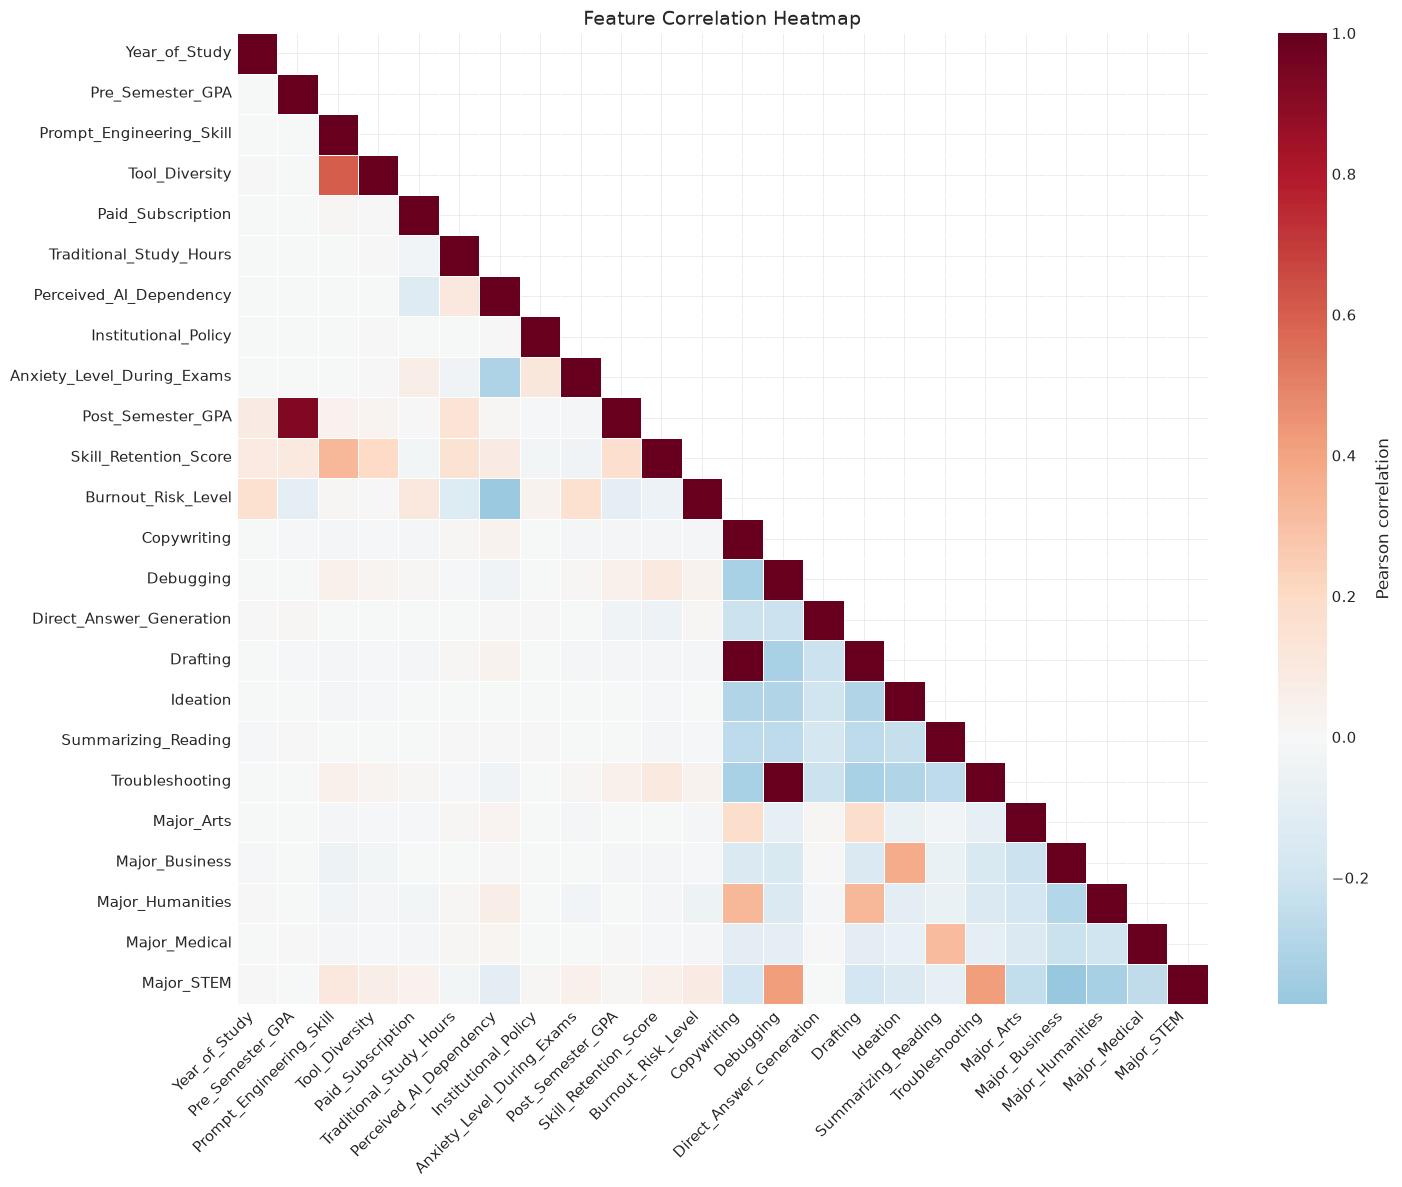

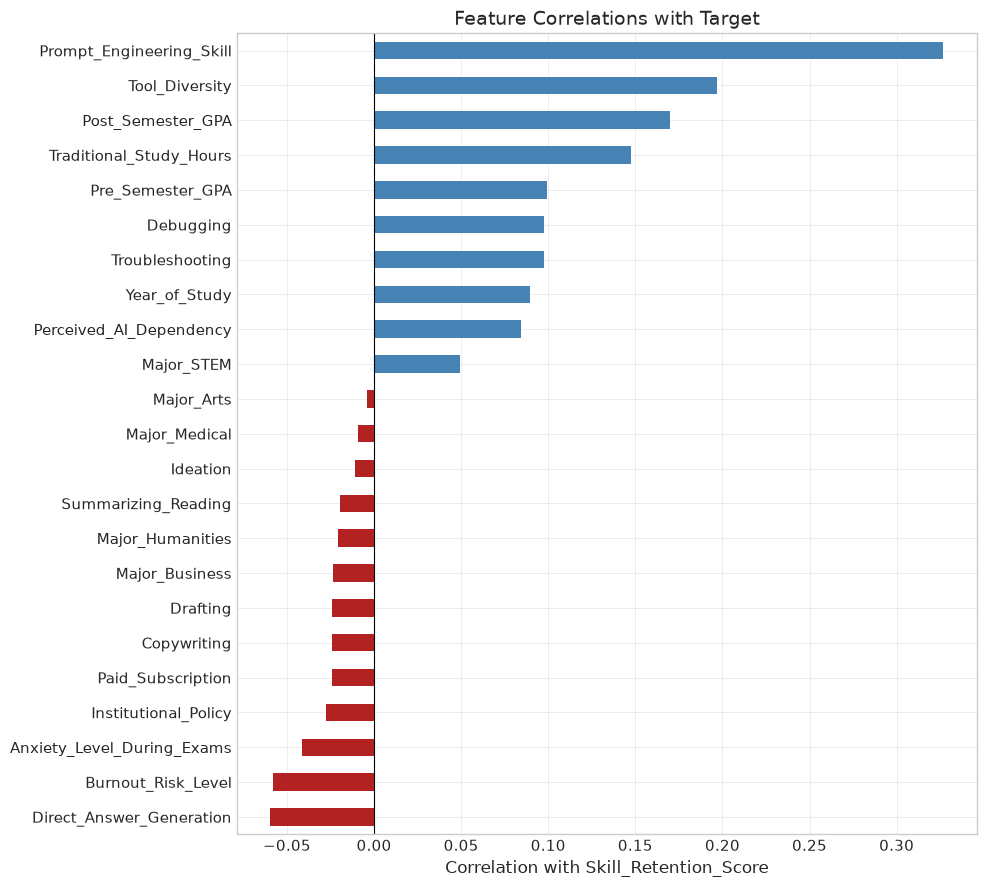

In [70]:
corr_df = df_proc.copy()
for col in corr_df.select_dtypes(include='bool').columns:
    corr_df[col] = corr_df[col].astype(int)
corr = corr_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'label': 'Pearson correlation'})
plt.title('Feature Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

target_corr = corr['Skill_Retention_Score'].drop('Skill_Retention_Score').sort_values()
plt.figure(figsize=(10, 9))
colors = ['firebrick' if v < 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Correlation with Skill_Retention_Score')
plt.title('Feature Correlations with Target')
plt.tight_layout()
plt.show()

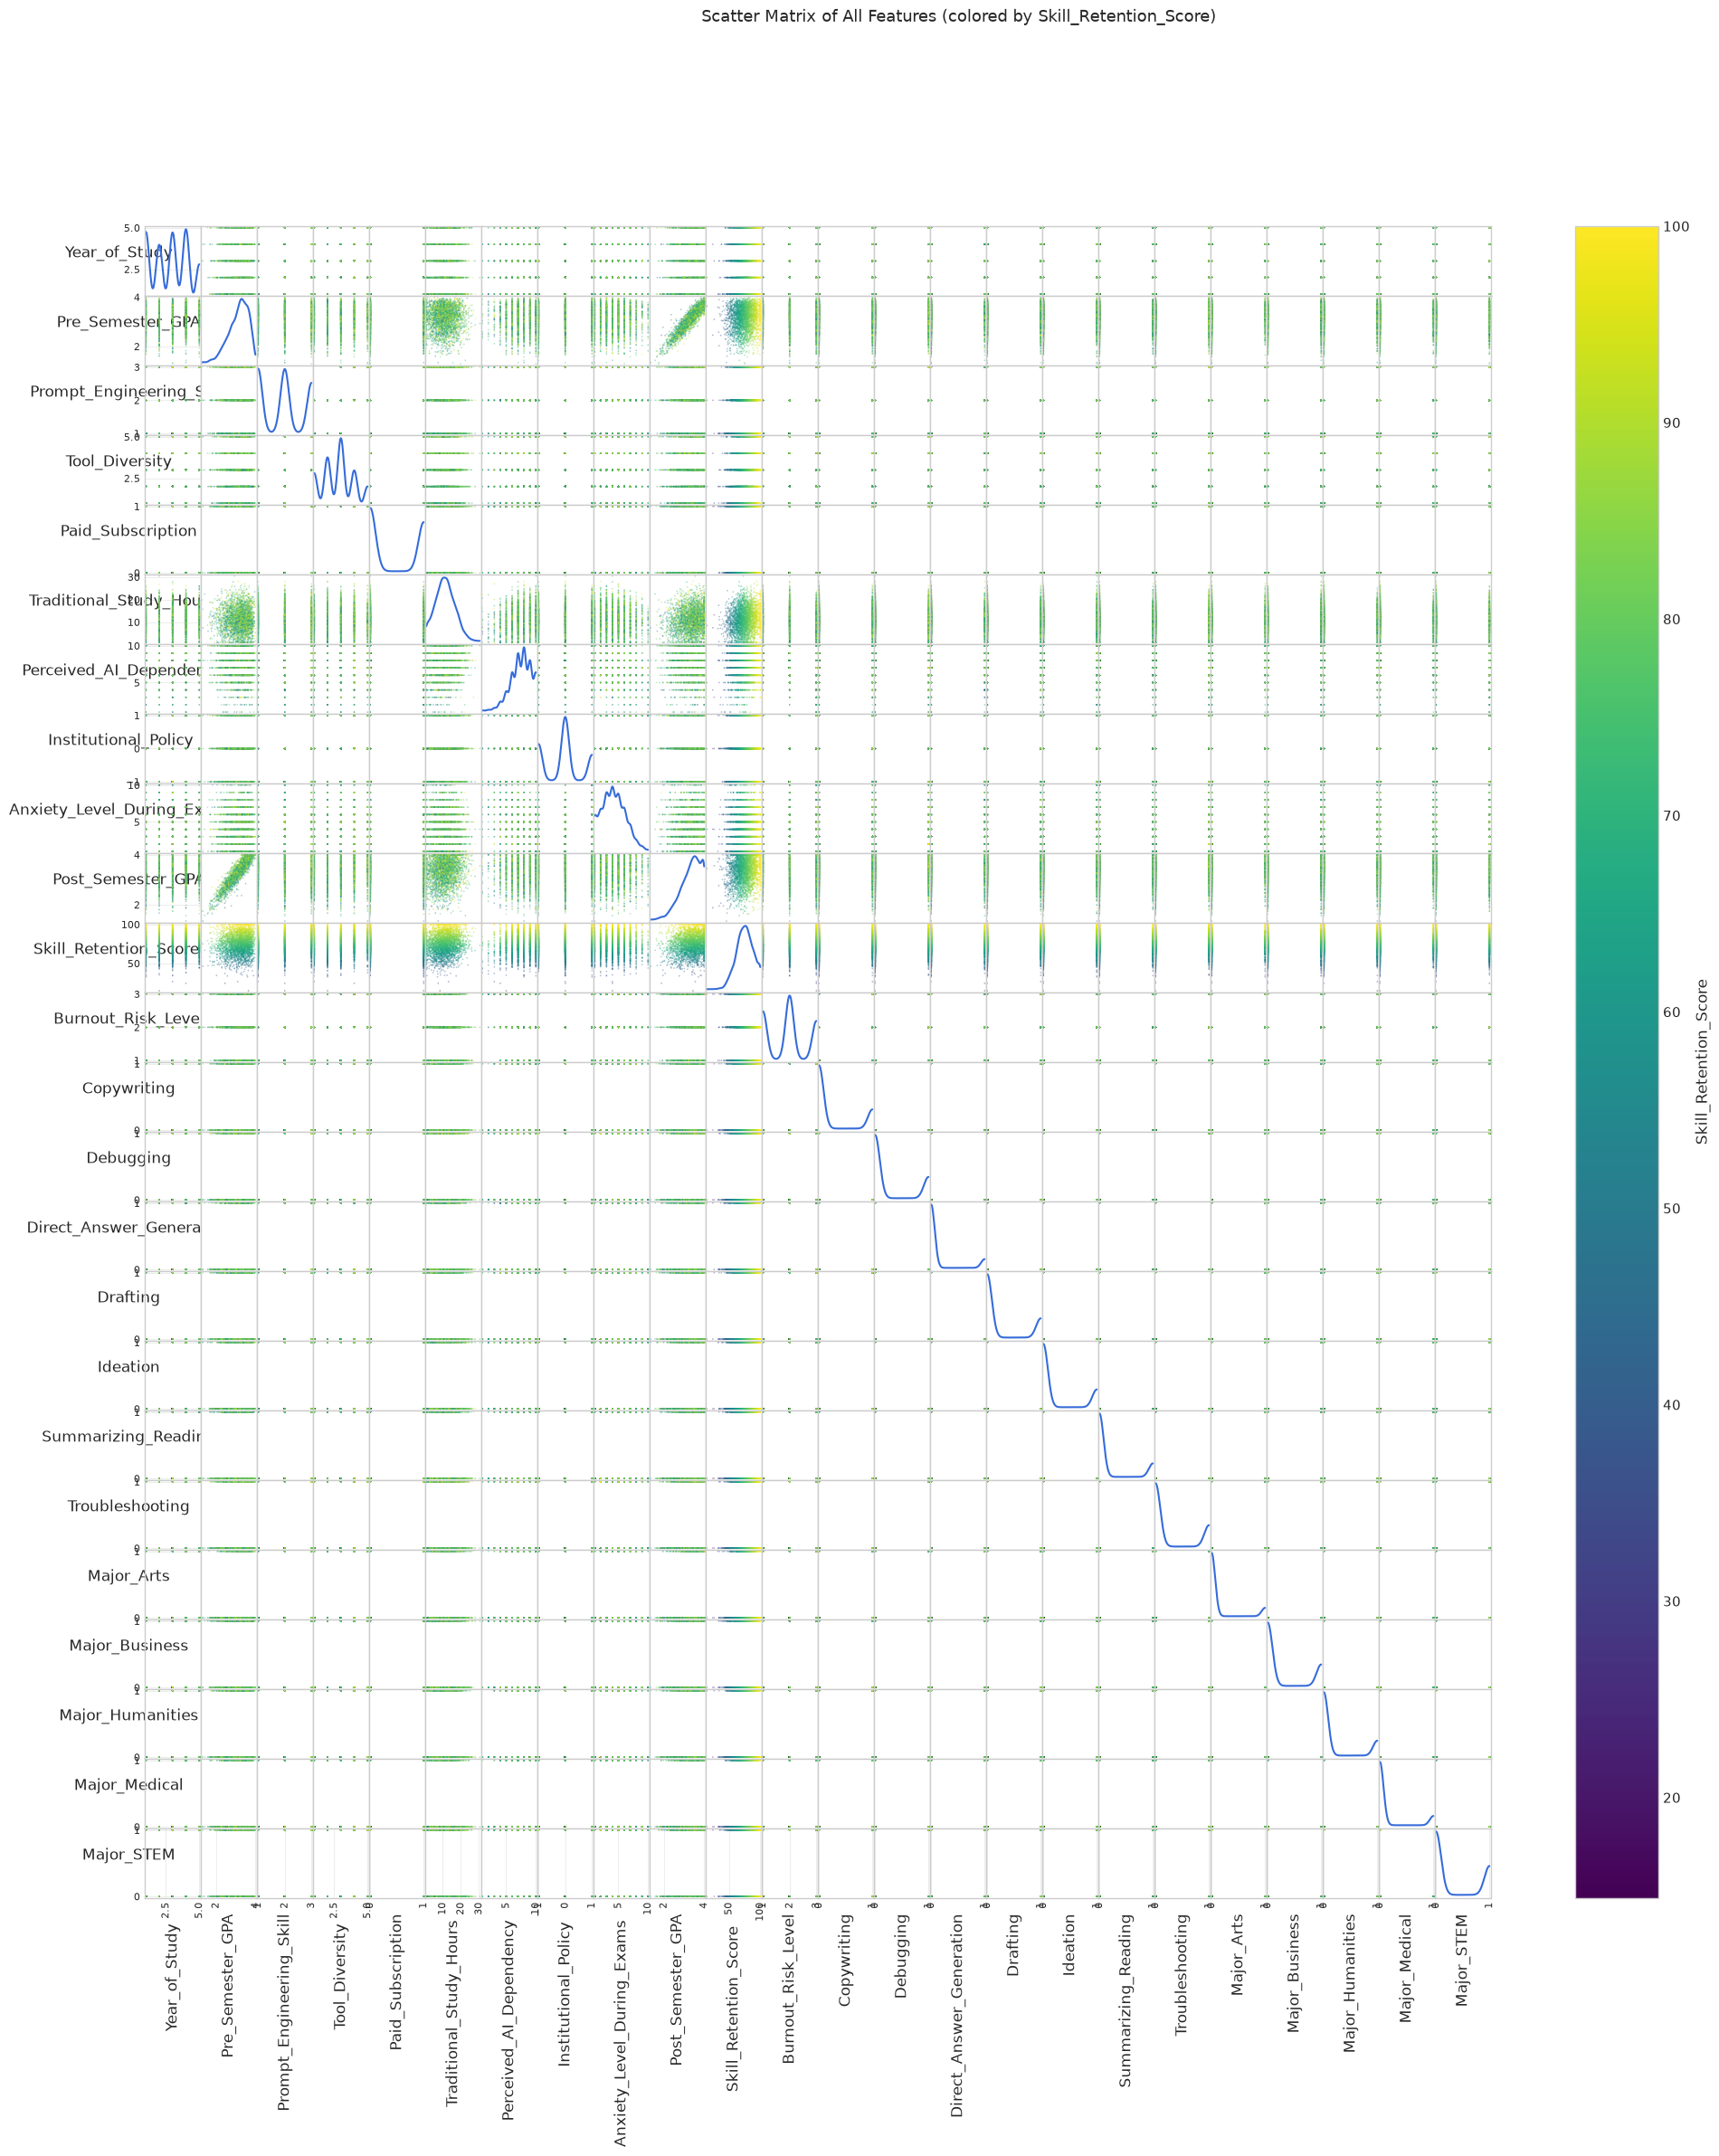

In [71]:
scatter_sample = df_proc.sample(n=3000, random_state=42)
for col in scatter_sample.select_dtypes(include='bool').columns:
    scatter_sample[col] = scatter_sample[col].astype(int)

axes = pd.plotting.scatter_matrix(scatter_sample,
                                  c=scatter_sample['Skill_Retention_Score'], cmap='viridis',
                                  diagonal='kde', figsize=(24, 24), s=6, alpha=0.4)

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.tick_params(axis='x', labelrotation=90)
    ax.tick_params(axis='y', labelrotation=0)

mappable = plt.cm.ScalarMappable(cmap='viridis',
                                norm=plt.Normalize(scatter_sample['Skill_Retention_Score'].min(),
                                                    scatter_sample['Skill_Retention_Score'].max()))
plt.colorbar(mappable, ax=axes, label='Skill_Retention_Score')
plt.suptitle('Scatter Matrix of All Features (colored by Skill_Retention_Score)')
plt.show()

In [72]:
X = df_proc.drop(columns=['Skill_Retention_Score', 'Student_ID'],errors='ignore')
Y = df_proc['Skill_Retention_Score']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

Now we test several regression models to see how differently they behave on this data: a simple Linear Regression, Bayesian Ridge, a Random Forest, and a Polynomial Regression of degree 2. For each one we fit on the training set and report MAE, MSE, RMSE and R2 on the test set, so we can compare them side by side.


In [73]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

lr = LinearRegression()
by = BayesianRidge()
rf = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
poly = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())


lr.fit(X_train, Y_train)
by.fit(X_train, Y_train)
rf.fit(X_train, Y_train)
poly.fit(X_train, Y_train)


Y_lr_pred = lr.predict(X_test)
Y_by_pred = by.predict(X_test)
Y_rf_pred = rf.predict(X_test)
Y_poly_pred = poly.predict(X_test)


mae_lr = mean_absolute_error(Y_test, Y_lr_pred)
mae_by = mean_absolute_error(Y_test, Y_by_pred)
mae_rf = mean_absolute_error(Y_test, Y_rf_pred)
mae_poly = mean_absolute_error(Y_test, Y_poly_pred)


mse_lr = mean_squared_error(Y_test, Y_lr_pred)
mse_by = mean_squared_error(Y_test, Y_by_pred)
mse_rf = mean_squared_error(Y_test, Y_rf_pred)
mse_poly = mean_squared_error(Y_test, Y_poly_pred)


rmse_lr = np.sqrt(mse_lr)
rmse_by = np.sqrt(mse_by)
rmse_rf = np.sqrt(mse_rf)
rmse_poly = np.sqrt(mse_poly)


r2_lr = r2_score(Y_test, Y_lr_pred)
r2_by = r2_score(Y_test, Y_by_pred)
r2_rf = r2_score(Y_test, Y_rf_pred)
r2_poly = r2_score(Y_test, Y_poly_pred)


metrics_lr = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae_lr, mse_lr, rmse_lr, r2_lr ],
    'Interpretation': [
        f'{mae_lr:.2f}',
        f'{mse_lr:.2f}',
        f'{rmse_lr:.2f}',
        f'{r2_lr*100:.2f}',
    ]
})

metrics_by = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae_by, mse_by, rmse_by, r2_by ],
    'Interpretation': [
        f'{mae_by:.2f}',
        f'{mse_by:.2f}',
        f'{rmse_by:.2f}',
        f'{r2_by*100:.2f}',
    ]
})

metrics_rf = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae_rf, mse_rf, rmse_rf, r2_rf ],
    'Interpretation': [
        f'{mae_rf:.2f}',
        f'{mse_rf:.2f}',
        f'{rmse_rf:.2f}',
        f'{r2_rf*100:.2f}',
    ]
})

metrics_poly = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae_poly, mse_poly, rmse_poly, r2_poly ],
    'Interpretation': [
        f'{mae_poly:.2f}',
        f'{mse_poly:.2f}',
        f'{rmse_poly:.2f}',
        f'{r2_poly*100:.2f}',
    ]
})


print("Linear Regression model performance:")
print(metrics_lr.to_string(index=False))

print("Bayesian Regression model performance:")
print(metrics_by.to_string(index=False))

print("Random Forest model performance:")
print(metrics_rf.to_string(index=False))

print("Polynomial Regression (degree 2) model performance:")
print(metrics_poly.to_string(index=False))


Linear Regression model performance:
Metric      Value Interpretation
   MAE   9.754777           9.75
   MSE 145.873824         145.87
  RMSE  12.077824          12.08
    R2   0.170999          17.10
Bayesian Regression model performance:
Metric      Value Interpretation
   MAE   9.755256           9.76
   MSE 145.889317         145.89
  RMSE  12.078465          12.08
    R2   0.170911          17.09
Random Forest model performance:
Metric      Value Interpretation
   MAE   9.749904           9.75
   MSE 147.063888         147.06
  RMSE  12.126990          12.13
    R2   0.164236          16.42
Polynomial Regression (degree 2) model performance:
Metric      Value Interpretation
   MAE   9.601261           9.60
   MSE 141.126702         141.13
  RMSE  11.879676          11.88
    R2   0.197977          19.80


To make sure we are not missing any hidden structure in the data, we try several feature transformations and see how each one affects the models: the original data, log, square root, a clipped exponential, standardization, min-max scaling, and Yeo-Johnson. We run each transformed dataset through the same set of models and collect MAE, RMSE and R2 into a single comparison table.


   Transform                 Model      MAE      RMSE       R2
    original      LinearRegression 9.754777 12.077824 0.170999
    original         BayesianRidge 9.755256 12.078465 0.170911
    original RandomForestRegressor 9.749904 12.126990 0.164236
    original      Poly2 (degree 2) 9.601261 11.879676 0.197977
       log1p      LinearRegression 9.760478 12.082043 0.170420
       log1p         BayesianRidge 9.760970 12.082871 0.170306
       log1p RandomForestRegressor 9.768705 12.140144 0.162422
       log1p      Poly2 (degree 2) 9.616633 11.890392 0.196529
        sqrt      LinearRegression 9.757572 12.080641 0.170612
        sqrt         BayesianRidge 9.758123 12.081477 0.170498
        sqrt RandomForestRegressor 9.768803 12.140545 0.162367
        sqrt      Poly2 (degree 2) 9.610268 11.883568 0.197451
 exp_clipped      LinearRegression 9.791322 12.115260 0.165852
 exp_clipped         BayesianRidge 9.791286 12.115035 0.165883
 exp_clipped RandomForestRegressor 9.889363 12.309694 0

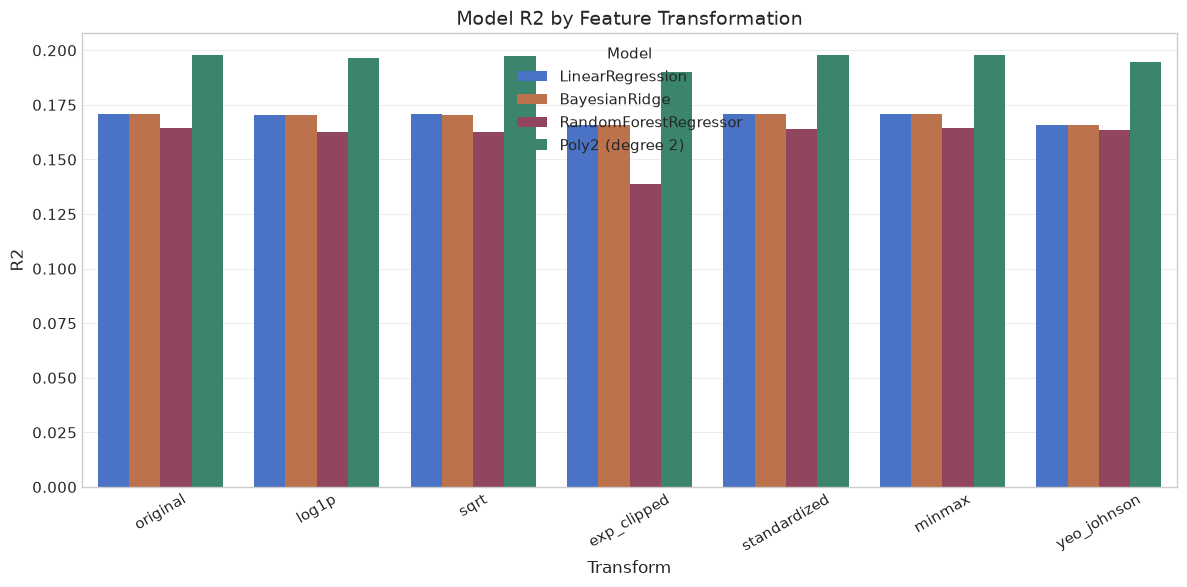

In [74]:
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, PolynomialFeatures
from sklearn.pipeline import make_pipeline

def std_pair(Xtr, Xte):
    sc = StandardScaler().fit(Xtr)
    return sc.transform(Xtr), sc.transform(Xte)

def minmax_pair(Xtr, Xte):
    sc = MinMaxScaler().fit(Xtr)
    return sc.transform(Xtr), sc.transform(Xte)

def yj_pair(Xtr, Xte):
    pt = PowerTransformer(method='yeo-johnson').fit(Xtr)
    return pt.transform(Xtr), pt.transform(Xte)

transformations = {
    'original': lambda Xtr, Xte: (Xtr, Xte),
    'log1p': lambda Xtr, Xte: (np.log1p(Xtr), np.log1p(Xte)),
    'sqrt': lambda Xtr, Xte: (np.sqrt(Xtr), np.sqrt(Xte)),
    'exp_clipped': lambda Xtr, Xte: (np.exp(np.clip(Xtr, -5, 5)), np.exp(np.clip(Xte, -5, 5))),
    'standardized': std_pair,
    'minmax': minmax_pair,
    'yeo_johnson': yj_pair,
}

results = []
for name, transform in transformations.items():
    Xtr, Xte = transform(X_train, X_test)
    Xtr = np.nan_to_num(Xtr, nan=0.0, posinf=0.0, neginf=0.0)
    Xte = np.nan_to_num(Xte, nan=0.0, posinf=0.0, neginf=0.0)
    models = {
        'LinearRegression': LinearRegression().fit(Xtr, Y_train),
        'BayesianRidge': BayesianRidge().fit(Xtr, Y_train),
        'RandomForestRegressor': RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1).fit(Xtr, Y_train),
        'Poly2 (degree 2)': make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression()).fit(Xtr, Y_train),

    }
    for model_name, model in models.items():
        pred = model.predict(Xte)
        results.append({
            'Transform': name,
            'Model': model_name,
            'MAE': mean_absolute_error(Y_test, pred),
            'RMSE': np.sqrt(mean_squared_error(Y_test, pred)),
            'R2': r2_score(Y_test, pred),
        })

comp = pd.DataFrame(results)
print(comp.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=comp, x='Transform', y='R2', hue='Model')
plt.xticks(rotation=30)
plt.title('Model R2 by Feature Transformation')
plt.tight_layout()
plt.show()

# before removing outliers
#    Transform                 Model      MAE      RMSE       R2
#     original      LinearRegression 9.722118 12.028857 0.177707
#     original         BayesianRidge 9.722725 12.029524 0.177616
#     original RandomForestRegressor 9.657650 11.984135 0.183810
#     original      Poly2 (degree 2) 9.549835 11.795101 0.209356
#     original      Poly3 (degree 3) 9.661546 11.967328 0.186098
#        log1p      LinearRegression 9.785442 12.115341 0.165841
#        log1p         BayesianRidge 9.785838 12.116094 0.165737
#        log1p RandomForestRegressor 9.686236 12.014404 0.179682
#        log1p      Poly2 (degree 2) 9.605675 11.882203 0.197636
#        log1p      Poly3 (degree 3) 9.679897 11.994649 0.182378
#         sqrt      LinearRegression 9.763970 12.087262 0.169703
#         sqrt         BayesianRidge 9.764610 12.088050 0.169595
#         sqrt RandomForestRegressor 9.686545 12.014726 0.179638
#         sqrt      Poly2 (degree 2) 9.571259 11.833703 0.204173
#         sqrt      Poly3 (degree 3) 9.675452 11.988704 0.183188
#  exp_clipped      LinearRegression 9.845268 12.183008 0.156497
#  exp_clipped         BayesianRidge 9.845228 12.182966 0.156503
#  exp_clipped RandomForestRegressor 9.882811 12.259701 0.145844
#  exp_clipped      Poly2 (degree 2) 9.664407 11.980887 0.184253
#  exp_clipped      Poly3 (degree 3) 9.782191 12.124873 0.164528
# standardized      LinearRegression 9.722118 12.028857 0.177707
# standardized         BayesianRidge 9.722518 12.029170 0.177665
# standardized RandomForestRegressor 9.659968 11.986943 0.183428
# standardized      Poly2 (degree 2) 9.549835 11.795101 0.209356
# standardized      Poly3 (degree 3) 9.656293 11.961568 0.186881
#       minmax      LinearRegression 9.722118 12.028857 0.177707
#       minmax         BayesianRidge 9.722742 12.029617 0.177604
#       minmax RandomForestRegressor 9.659947 11.986305 0.183515
#       minmax      Poly2 (degree 2) 9.549835 11.795101 0.209356
#       minmax      Poly3 (degree 3) 9.656293 11.961568 0.186881
#  yeo_johnson      LinearRegression 9.779524 12.114706 0.165928
#  yeo_johnson         BayesianRidge 9.779852 12.114900 0.165902
#  yeo_johnson RandomForestRegressor 9.661199 11.984191 0.183803
#  yeo_johnson      Poly2 (degree 2) 9.598561 11.866334 0.199778
#  yeo_johnson      Poly3 (degree 3) 9.667936 11.977558 0.184706

# results after removing outliers
#     Transform                 Model      MAE      RMSE       R2
#     original      LinearRegression 9.726274 12.009972 0.160737
#     original         BayesianRidge 9.726432 12.010055 0.160725
#     original RandomForestRegressor 9.733202 12.083121 0.150482
#     original      Poly2 (degree 2) 9.603320 11.886829 0.177859
#     original      Poly3 (degree 3) 9.713326 12.056795 0.154180
#        log1p      LinearRegression 9.863556 12.168246 0.138470
#        log1p         BayesianRidge 9.863979 12.168493 0.138436
#        log1p RandomForestRegressor 9.745121 12.104547 0.147467
#        log1p      Poly2 (degree 2) 9.715689 12.022204 0.159026
#        log1p      Poly3 (degree 3) 9.823911 12.206574 0.133035
#         sqrt      LinearRegression 9.785301 12.073565 0.151825
#         sqrt         BayesianRidge 9.785548 12.073750 0.151799
#         sqrt RandomForestRegressor 9.904666 12.330085 0.115401
#         sqrt      Poly2 (degree 2) 9.644572 11.943698 0.169974
#         sqrt      Poly3 (degree 3) 9.716216 12.087362 0.149886
#  exp_clipped      LinearRegression 9.771083 12.071608 0.152100
#  exp_clipped         BayesianRidge 9.770822 12.071327 0.152140
#  exp_clipped RandomForestRegressor 9.730744 12.081765 0.150673
#  exp_clipped      Poly2 (degree 2) 9.608787 11.900755 0.175932
#  exp_clipped      Poly3 (degree 3) 9.672047 12.010782 0.160624
# standardized      LinearRegression 9.726274 12.009972 0.160737
# standardized         BayesianRidge 9.726417 12.010049 0.160726
# standardized RandomForestRegressor 9.733210 12.081995 0.150641
# standardized      Poly2 (degree 2) 9.603320 11.886829 0.177859
# standardized      Poly3 (degree 3) 9.713326 12.056795 0.154180
#       minmax      LinearRegression 9.726274 12.009972 0.160737
#       minmax         BayesianRidge 9.726253 12.009938 0.160742
#       minmax RandomForestRegressor 9.732841 12.082810 0.150526
#       minmax      Poly2 (degree 2) 9.603320 11.886829 0.177859
#       minmax      Poly3 (degree 3) 9.713326 12.056795 0.154180
#  yeo_johnson      LinearRegression 9.743757 12.027772 0.158247
#  yeo_johnson         BayesianRidge 9.743866 12.027833 0.158239
#  yeo_johnson RandomForestRegressor 9.732021 12.082261 0.150603
#  yeo_johnson      Poly2 (degree 2) 9.615647 11.900353 0.175987
#  yeo_johnson      Poly3 (degree 3) 9.708427 12.052192 0.154826

#conclusion: dont remove outliers

Since the scatter plots suggested some overlap between `Pre_Semester_GPA` and `Post_Semester_GPA`, and between `Perceived_AI_Dependency` and `Traditional_Study_Hours`, we try combining each of those pairs into a single PCA component. The idea is that the shared variance of each pair might carry a stronger signal for the target than the two columns separately. We then retrain the degree-2 polynomial on the PCA-reduced data and compare it to the baseline.


In [75]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

# Combine correlated feature pairs into a single PCA component each, then retry Poly2
gpa_pair = ['Pre_Semester_GPA', 'Post_Semester_GPA']
habit_pair = ['Perceived_AI_Dependency', 'Traditional_Study_Hours']

def combine_pair(Xtr, Xte, cols, name):
    pca_pipe = make_pipeline(StandardScaler(), PCA(n_components=1)).fit(Xtr[cols])
    tr_comp = pca_pipe.transform(Xtr[cols])
    te_comp = pca_pipe.transform(Xte[cols])
    Xtr = Xtr.drop(columns=cols).copy()
    Xte = Xte.drop(columns=cols).copy()
    Xtr[name] = tr_comp
    Xte[name] = te_comp
    return Xtr, Xte, pca_pipe

Xtr_pca, Xte_pca, pca_gpa = combine_pair(X_train, X_test, gpa_pair, 'PCA_GPA')
Xtr_pca, Xte_pca, pca_habit = combine_pair(Xtr_pca, Xte_pca, habit_pair, 'PCA_StudyHabit')

print('PCA_GPA explained variance ratio:', pca_gpa.named_steps['pca'].explained_variance_ratio_)
print('PCA_StudyHabit explained variance ratio:', pca_habit.named_steps['pca'].explained_variance_ratio_)

poly_pca = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_pca.fit(Xtr_pca, Y_train)
pred_pca = poly_pca.predict(Xte_pca)

print()
print('Poly2 (degree 2) with PCA-combined pairs:')
print(f'  MAE : {mean_absolute_error(Y_test, pred_pca):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(Y_test, pred_pca)):.4f}')
print(f'  R2  : {r2_score(Y_test, pred_pca):.4f}')
print(f'  baseline Poly2 R2: {r2_poly:.4f}')


PCA_GPA explained variance ratio: [0.96339778]
PCA_StudyHabit explained variance ratio: [0.55106583]

Poly2 (degree 2) with PCA-combined pairs:
  MAE : 9.6666
  RMSE: 11.9619
  R2  : 0.1868
  baseline Poly2 R2: 0.1980


The variance for these features is better defined, but this doesn't help with the results.

We plot the residuals (actual minus predicted) to visualize the errors. For each model we look at: the actual-vs-predicted scatter (perfect predictions would fall on the red diagonal), the residuals plotted against the predictions (to check for patterns that would mean the model is missing structure), and the distribution of the residuals (to check they are roughly centered around zero and normally distributed).


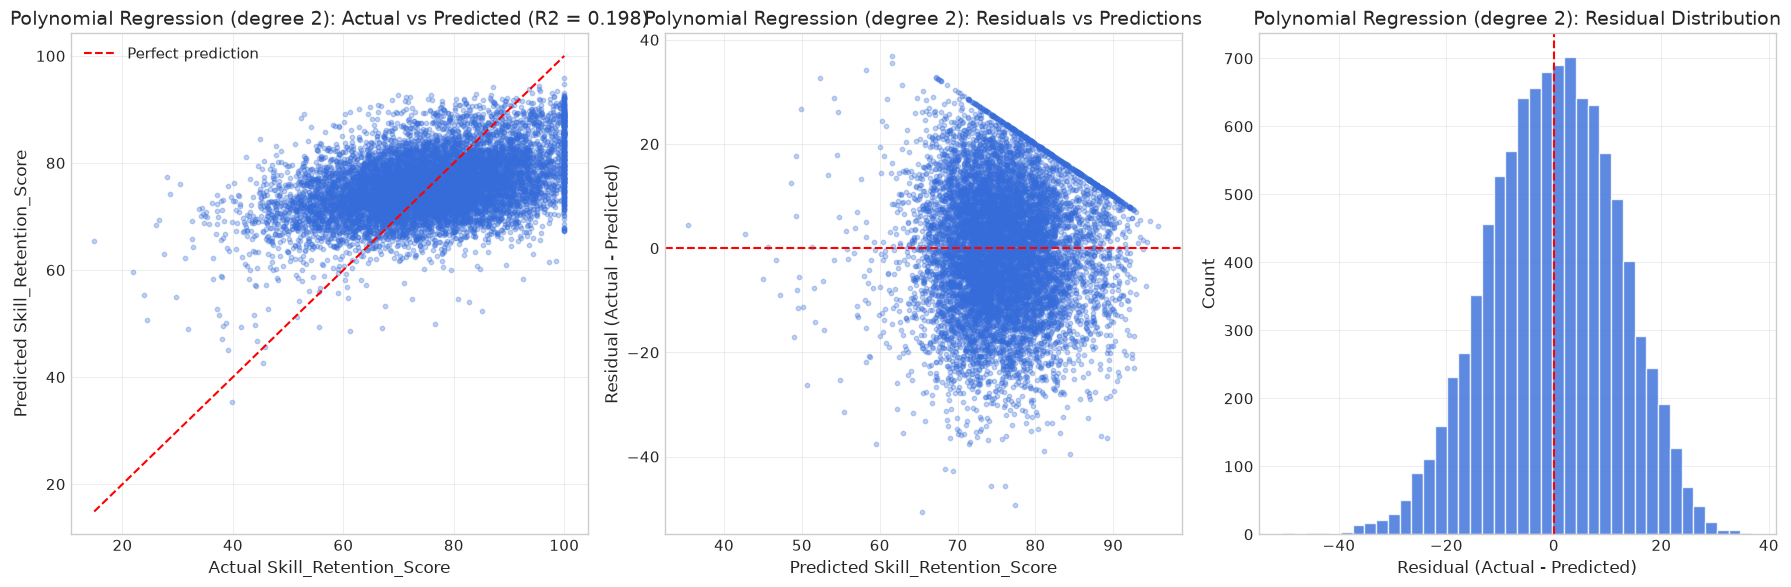

In [83]:
residuals_poly = Y_test - Y_poly_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for row, (pred, residuals, r2, title) in enumerate([
    (Y_poly_pred, residuals_poly, r2_poly, 'Polynomial Regression (degree 2)'),
]):
    axes[0].scatter(Y_test, pred, alpha=0.3, s=10)
    lims = [min(Y_test.min(), pred.min()), max(Y_test.max(), pred.max())]
    axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    axes[0].set_xlabel('Actual Skill_Retention_Score')
    axes[0].set_ylabel('Predicted Skill_Retention_Score')
    axes[0].set_title(f'{title}: Actual vs Predicted (R2 = {r2:.3f})')
    axes[0].legend()

    axes[1].scatter(pred, residuals, alpha=0.3, s=10)
    axes[1].axhline(0, color='r', linestyle='--', lw=1.5)
    axes[1].set_xlabel('Predicted Skill_Retention_Score')
    axes[1].set_ylabel('Residual (Actual - Predicted)')
    axes[1].set_title(f'{title}: Residuals vs Predictions')

    axes[2].hist(residuals, bins=40, edgecolor='white', alpha=0.8)
    axes[2].axvline(0, color='r', linestyle='--', lw=1.5)
    axes[2].set_xlabel('Residual (Actual - Predicted)')
    axes[2].set_ylabel('Count')
    axes[2].set_title(f'{title}: Residual Distribution')

plt.tight_layout()
plt.show()

                Model  Train R2  Test R2  Gap (Train - Test)
     LinearRegression  0.169675 0.170999           -0.001324
        BayesianRidge  0.169662 0.170911           -0.001249
RandomForestRegressor  0.881446 0.164236            0.717210
     Poly2 (degree 2)  0.201954 0.197977            0.003977


<Figure size 1200x600 with 0 Axes>

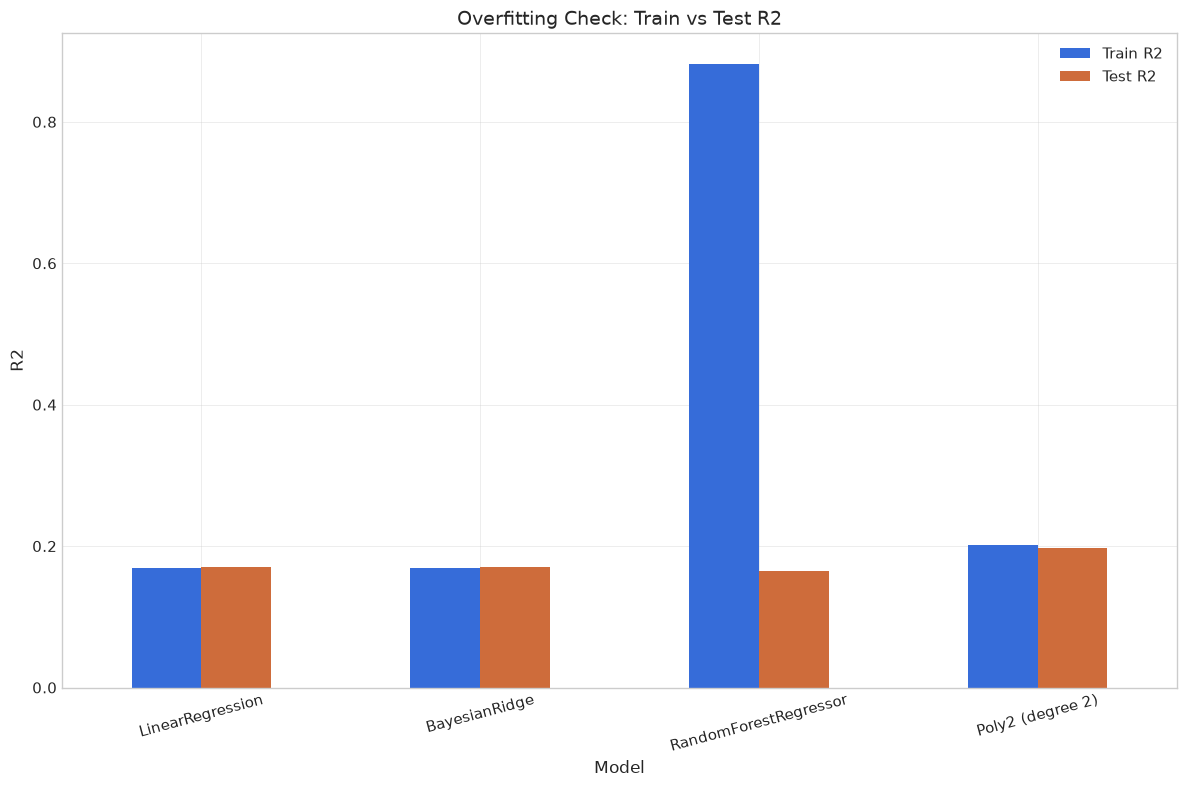

In [77]:
overfit_models = {
    'LinearRegression': lr,
    'BayesianRidge': by,
    'RandomForestRegressor': rf,
    'Poly2 (degree 2)': poly,
}

overfit_rows = []
for name, model in overfit_models.items():
    train_r2 = r2_score(Y_train, model.predict(X_train))
    test_r2 = r2_score(Y_test, model.predict(X_test))
    overfit_rows.append({
        'Model': name,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Gap (Train - Test)': train_r2 - test_r2,
    })

overfit = pd.DataFrame(overfit_rows)
print(overfit.to_string(index=False))

plt.figure(figsize=(12, 6))
overfit.set_index('Model')[['Train R2', 'Test R2']].plot(kind='bar')
plt.ylabel('R2')
plt.title('Overfitting Check: Train vs Test R2')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Summary of everything I tried so far and what happened:
- Removed some columns that seemed less related: removing some didn't change the outcome, others made it worse.
- Removed outliers: it made the results worse.
- Tried different transformations of the dataset to look for hidden patterns: didn't find any.
- Plotted scatter plots to see how features depend on each other.
- Based on the scatter plots, tried PCA on the correlated pairs: it also did worse.

The consistent picture is that none of these approaches moved the R2, which points to the data itself being the limit (see the section below).


## Why the R2 won't go above ~0.20

The ceiling comes from the data itself, not from the models. The target `Skill_Retention_Score` is almost independent of every feature we have.

**The features carry almost no signal about the target.** The single strongest feature is `Prompt_Engineering_Skill` with a correlation of only 0.327 (R2 = 0.107 when used alone). Every other feature is far weaker:



In [78]:
# Correlation of every feature with the target, and the R2 it would give if used alone
corr_df = df_proc.copy()
for col in corr_df.select_dtypes(include='bool').columns:
    corr_df[col] = corr_df[col].astype(int)

corr_table = corr_df.corr()['Skill_Retention_Score'].drop('Skill_Retention_Score').to_frame('Correlation')
corr_table['R2 if used alone'] = corr_table['Correlation'] ** 2
corr_table = corr_table.reindex(corr_table['Correlation'].abs().sort_values(ascending=False).index)

corr_table.round(3).head()


,Correlation,R2 if used alone
Prompt_Engineering_Skill,0.327,0.107
Tool_Diversity,0.197,0.039
Post_Semester_GPA,0.170,0.029
Traditional_Study_Hours,0.148,0.022
Pre_Semester_GPA,0.099,0.010


A feature's maximum possible R2 is its correlation squared, so the best feature can only reach ~0.11 on its own. Combining many weak features only gets us to ~0.18-0.21, which is exactly what we see.

**The residuals confirm it.** The target's standard deviation is ~13.3, while the best linear model's residuals have a standard deviation of ~12.0. That means ~82% of the target's variance is left unexplained - it is effectively noise relative to our features.

**The overfitting check shows this** The Random Forest reaches 0.885 on the training set but only 0.184 on the test set. It can memorize the training data (fit noise), but there is no generalizable pattern to learn, so test R2 stays stuck at ~0.20 no matter the model or transformation.

**Conclusion.** ~0.20 is the practical ceiling for this feature set achieved by polynomial of 2nd degree. Log/sqrt/Yeo-Johnson transformations and more complex models cannot fix it, because the problem is not model capacity. Research showed that the noisy data has very little traces of anomalies that can be used for prediction.